In [73]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from numpy import sqrt, linspace, zeros, ones, pi, argmin, exp, argmax, sinh, sin, conj
from scipy.linalg import expm
from numpy import abs

In [120]:
alpha = 1/137 # Fine structure constant
sigma = (pi*alpha) # graphene conductivity in units of c*epsilon_0
r = -(sigma)/(sigma+2)
t = 2/(sigma+2)
transfer_matrix = np.array([[t*(1-r**2/t**2), r/t], [-r/t, 1/t]])

In [130]:
def absorption(N, kd=0.1):
    phase_matrix = np.array([[np.exp(1j*kd), 0], [0, np.exp(-1j*kd)]])
    A = transfer_matrix @ np.linalg.matrix_power(phase_matrix @ transfer_matrix, N-1)
    t_total = A[0, 0]-A[0, 1]*A[1, 0]/A[1, 1]
    r_total = A[0, 1]/A[1, 1]
    return 1 - abs(t_total + r_total)**2

In [140]:
absorptions = zeros(200)
for n in range(0, 200):
    absorptions[n] = absorption(n+1, 0.01)

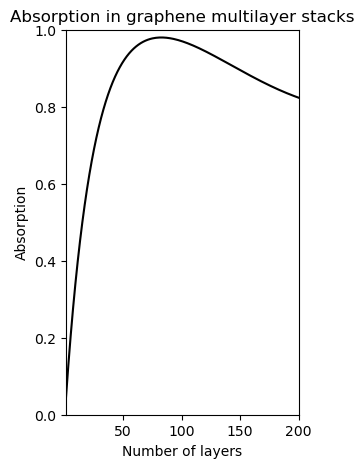

In [154]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.plot(np.linspace(1, 200, 200), absorptions, color="black")
ax.set_ylim(0, 1);
ax.set_xlim(1, 200);
ax.set_title("Absorption in graphene multilayer stacks")
ax.set_xlabel("Number of layers")
ax.set_ylabel("Absorption");